In [2]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    StratifiedKFold
)

from sklearn.preprocessing import MinMaxScaler

# Naive Bayes
from sklearn.naive_bayes import (
    GaussianNB,
    MultinomialNB,
    BernoulliNB
)

# KNN
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)

# Time Calculation
import time

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [7]:
#loading the load and displaying
df = pd.read_csv("spambase_csv.csv")
df.head(10)
print(df.shape)

df.info()

df.describe()

(4601, 58)
<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [8]:
df.isnull().sum()

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

In [9]:
X = df.iloc[:, :-1]

y = df.iloc[:, -1]

In [10]:
X.head()

y.value_counts()

class
0    2788
1    1813
Name: count, dtype: int64

In [11]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [12]:
X_scaled.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.000000,0.044818,0.125490,0.0,0.032,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.023955,0.000000,0.000000,0.002502,0.006007,0.017487
1,0.046256,0.019608,0.098039,0.0,0.014,0.047619,0.028886,0.006301,0.000000,0.051705,...,0.0,0.000000,0.013536,0.0,0.011454,0.029985,0.002421,0.003735,0.010012,0.064836
2,0.013216,0.000000,0.139216,0.0,0.123,0.032313,0.026135,0.010801,0.121673,0.013751,...,0.0,0.002281,0.014664,0.0,0.008498,0.030651,0.000504,0.008008,0.048458,0.142551
3,0.000000,0.000000,0.000000,0.0,0.063,0.000000,0.042641,0.056706,0.058935,0.034653,...,0.0,0.000000,0.014048,0.0,0.004218,0.000000,0.000000,0.002303,0.003905,0.011995
4,0.000000,0.000000,0.000000,0.0,0.063,0.000000,0.042641,0.056706,0.058935,0.034653,...,0.0,0.000000,0.013843,0.0,0.004157,0.000000,0.000000,0.002303,0.003905,0.011995


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
print(X_train.shape)

print(X_test.shape)

(3680, 57)
(921, 57)


In [15]:
#PLOTTING AND VISUALIZATION

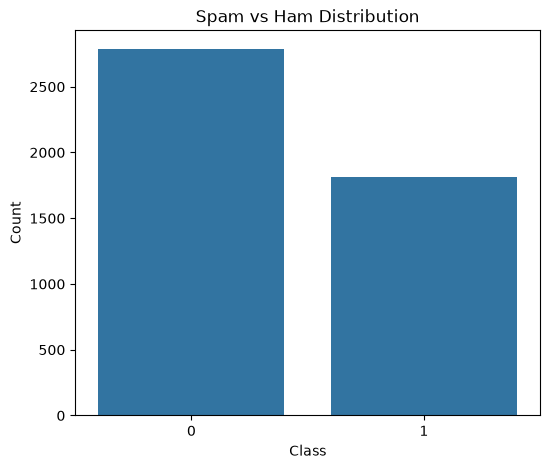

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(x=y)

plt.title("Spam vs Ham Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

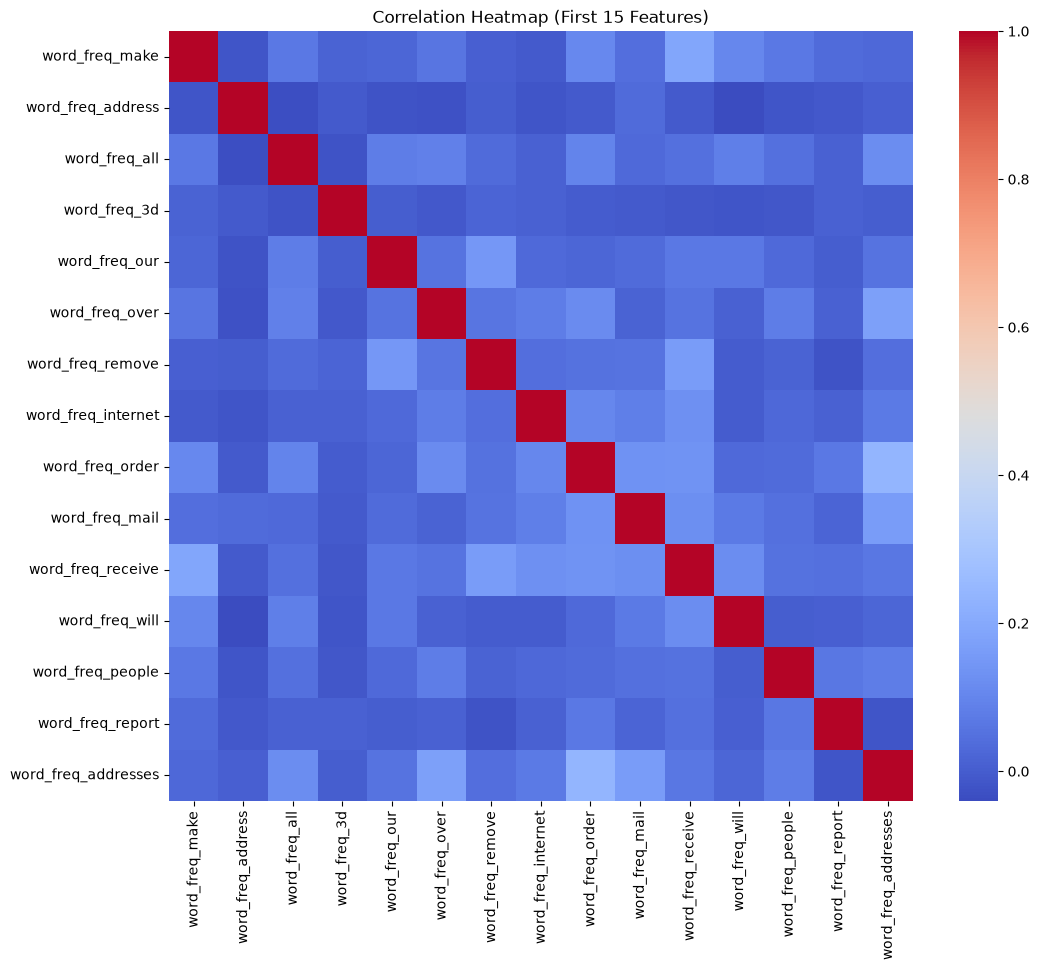

In [17]:
plt.figure(figsize=(12,10))

corr = df.iloc[:, :15].corr()

sns.heatmap(corr,
            cmap="coolwarm",
            annot=False)

plt.title("Correlation Heatmap (First 15 Features)")
plt.show()

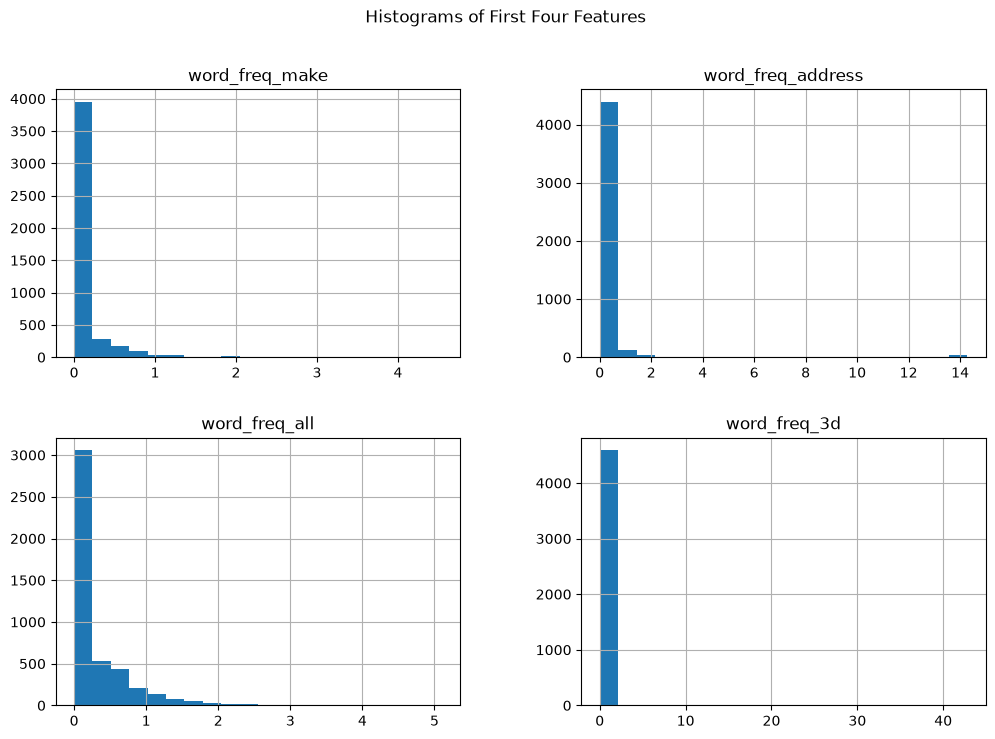

In [18]:
df.iloc[:, :4].hist(figsize=(12,8), bins=20)

plt.suptitle("Histograms of First Four Features")
plt.show()

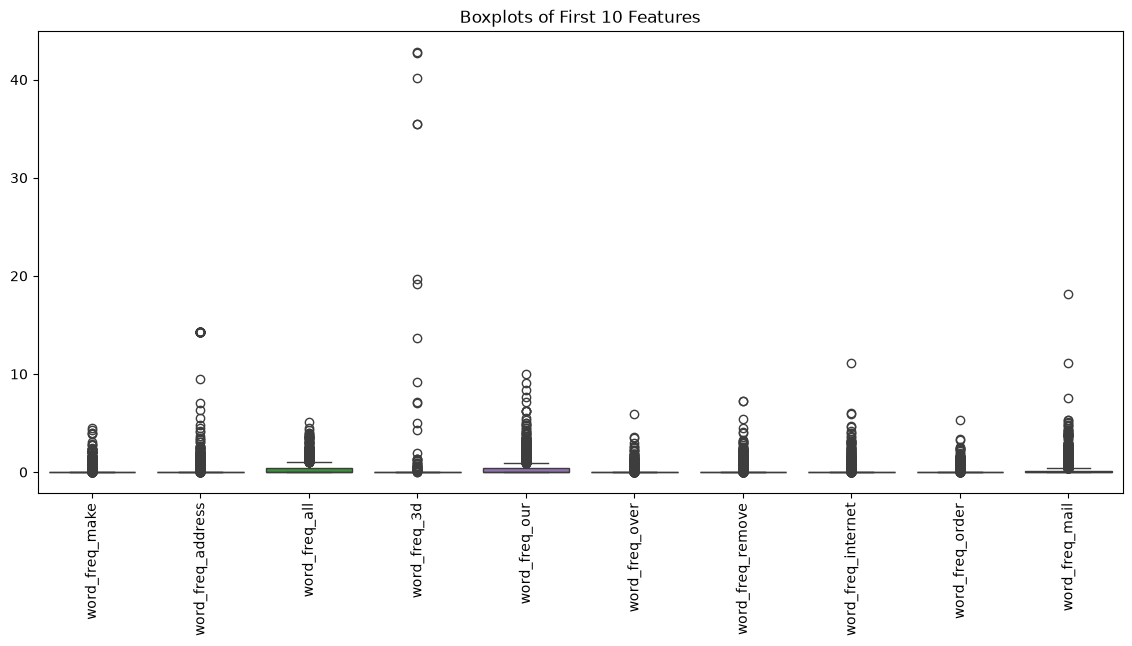

In [19]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df.iloc[:, :10])

plt.xticks(rotation=90)

plt.title("Boxplots of First 10 Features")

plt.show()

In [40]:

#NAIVE BAYES GAUSSIAN NAIVE BAYES
gnb = GaussianNB()

start_train = time.time()
gnb.fit(X_train, y_train)
gnb_train_time = time.time() - start_train
print("GuassianGb traing time:",gnb_train_time)

start_pred = time.time()
y_pred_gnb = gnb.predict(X_test)
gnb_pred_time = time.time() - start_pred
print("GuassiabGB testing time:",gnb_pred_time)
gnb_accuracy = accuracy_score(y_test, y_pred_gnb)
gnb_precision = precision_score(y_test, y_pred_gnb)
gnb_recall = recall_score(y_test, y_pred_gnb)
gnb_f1 = f1_score(y_test, y_pred_gnb)

gnb_prob = gnb.predict_proba(X_test)[:,1]
gnb_auc = roc_auc_score(y_test, gnb_prob)

print("Accuracy :", gnb_accuracy)
print("Precision:", gnb_precision)
print("Recall   :", gnb_recall)
print("F1 Score :", gnb_f1)
print("ROC AUC  :", gnb_auc)

GuassianGb traing time: 0.003612041473388672
GuassiabGB testing time: 0.0011649131774902344
Accuracy : 0.8327904451682954
Precision: 0.7145790554414785
Recall   : 0.9586776859504132
F1 Score : 0.8188235294117647
ROC AUC  : 0.9229168518024823


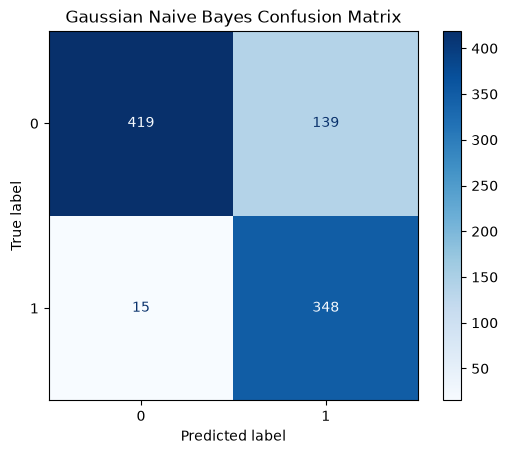

In [42]:
#PLOTTING
cm = confusion_matrix(y_test, y_pred_gnb)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")

plt.title("Gaussian Naive Bayes Confusion Matrix")

plt.show()

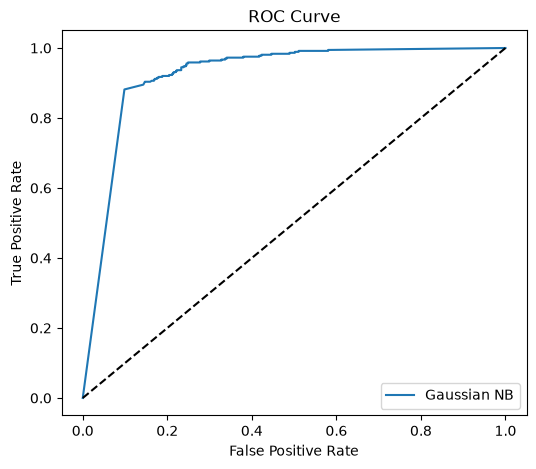

In [31]:
fpr, tpr, _ = roc_curve(y_test, gnb_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Gaussian NB")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

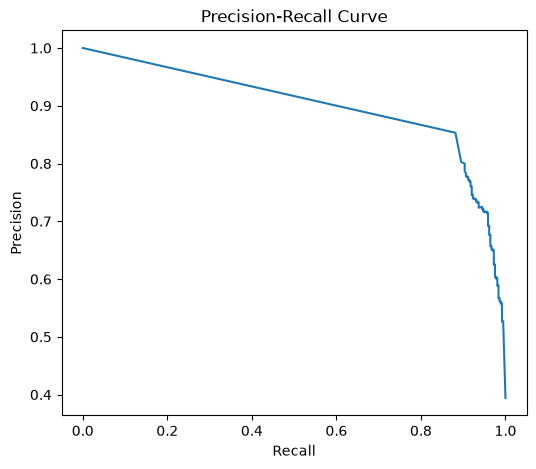

In [32]:
precision, recall, _ = precision_recall_curve(y_test, gnb_prob)

plt.figure(figsize=(6,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

In [34]:
#MULTINOMIAL NAIVE BAYES
mnb = MultinomialNB()

start_train = time.time()
mnb.fit(X_train, y_train)
mnb_train_time = time.time() - start_train
print("multinomial traing time:",mnb_train_time)
start_pred = time.time()
y_pred_mnb = mnb.predict(X_test)
mnb_pred_time = time.time() - start_pred
print("Multinomial testing time:",mnb_pred_time)
mnb_accuracy = accuracy_score(y_test, y_pred_mnb)
mnb_precision = precision_score(y_test, y_pred_mnb)
mnb_recall = recall_score(y_test, y_pred_mnb)
mnb_f1 = f1_score(y_test, y_pred_mnb)

mnb_prob = mnb.predict_proba(X_test)[:,1]
mnb_auc = roc_auc_score(y_test, mnb_prob)

print("Accuracy :", mnb_accuracy)
print("Precision:", mnb_precision)
print("Recall   :", mnb_recall)
print("F1 Score :", mnb_f1)
print("ROC AUC  :", mnb_auc)

multinomial traing time: 0.0044252872467041016
Multinomial testing time: 0.0010726451873779297
Accuracy : 0.8935939196525515
Precision: 0.9431438127090301
Recall   : 0.7768595041322314
F1 Score : 0.851963746223565
ROC AUC  : 0.9624544565893539


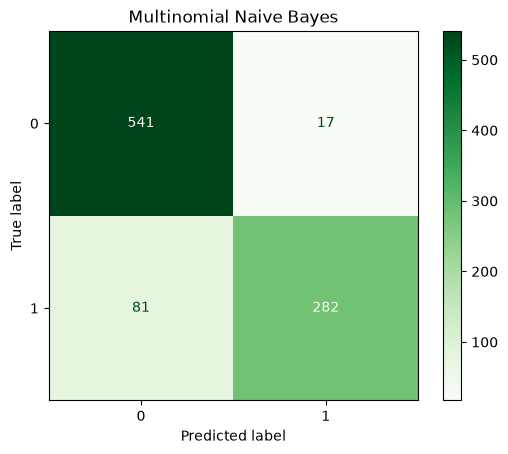

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_mnb,
    cmap="Greens"
)

plt.title("Multinomial Naive Bayes")

plt.show()

In [45]:

#BERNOULLIS NAIVE BAYES
X_train_binary = (X_train > 0.5).astype(int)
X_test_binary = (X_test > 0.5).astype(int)

bnb = BernoulliNB()

start_train = time.time()
bnb.fit(X_train_binary, y_train)
bnb_train_time = time.time() - start_train
print("traing",bnb_train_time)

start_pred = time.time()
y_pred_bnb = bnb.predict(X_test_binary)
bnb_pred_time = time.time() - start_pred
print("testing",bnb_pred_time)
bnb_accuracy = accuracy_score(y_test, y_pred_bnb)
bnb_precision = precision_score(y_test, y_pred_bnb)
bnb_recall = recall_score(y_test, y_pred_bnb)
bnb_f1 = f1_score(y_test, y_pred_bnb)

bnb_prob = bnb.predict_proba(X_test_binary)[:,1]
bnb_auc = roc_auc_score(y_test, bnb_prob)

print("Accuracy :", bnb_accuracy)
print("Precision:", bnb_precision)
print("Recall   :", bnb_recall)
print("F1 Score :", bnb_f1)
print("ROC AUC  :", bnb_auc)

traing 0.0068738460540771484
testing 0.0024492740631103516
Accuracy : 0.6340933767643865
Precision: 0.9642857142857143
Recall   : 0.0743801652892562
F1 Score : 0.13810741687979539
ROC AUC  : 0.587502591901419


In [46]:
k_values = [1, 3, 5, 7, 9, 11]

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

training_times = []
prediction_times = []
for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    start = time.time()
    knn.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = knn.predict(X_test)
    pred_time = time.time() - start

    accuracy_list.append(accuracy_score(y_test, y_pred))
    precision_list.append(precision_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))

    training_times.append(train_time)
    prediction_times.append(pred_time)

In [47]:
knn_table = pd.DataFrame({
    "k": k_values,
    "Accuracy": accuracy_list,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1": f1_list
})

knn_table

,k,Accuracy,Precision,Recall,F1
0,1,0.895765,0.867769,0.867769,0.867769
1,3,0.895765,0.882521,0.848485,0.865169
2,5,0.902280,0.876033,0.876033,0.876033
3,7,0.895765,0.876056,0.856749,0.866295
4,9,0.894680,0.886628,0.840220,0.862801
5,11,0.889251,0.882698,0.829201,0.855114


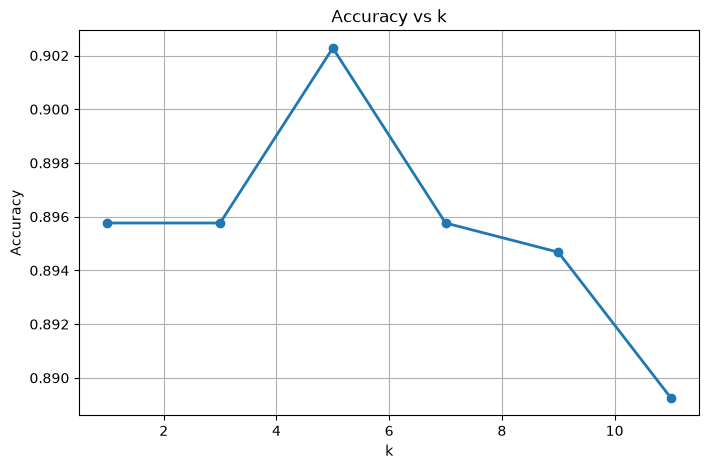

In [48]:
plt.figure(figsize=(8,5))

plt.plot(k_values,
         accuracy_list,
         marker='o',
         linewidth=2)

plt.title("Accuracy vs k")

plt.xlabel("k")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [49]:
best_k = k_values[np.argmax(accuracy_list)]

print("Best k =", best_k)

Best k = 5


In [51]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)

start = time.time()
best_knn.fit(X_train, y_train)
best_knn_train_time = time.time()-start
print("knn traing time",best_knn_train_time)

start = time.time()
best_pred = best_knn.predict(X_test)
best_knn_pred_time = time.time()-start
print("testing time:",best_knn_pred_time)
best_accuracy = accuracy_score(y_test,best_pred)

best_precision = precision_score(y_test,best_pred)

best_recall = recall_score(y_test,best_pred)

best_f1 = f1_score(y_test,best_pred)

best_prob = best_knn.predict_proba(X_test)[:,1]

best_auc = roc_auc_score(y_test,best_prob)

print("Accuracy :",best_accuracy)
print("Precision:",best_precision)
print("Recall :",best_recall)
print("F1 :",best_f1)
print("ROC AUC :",best_auc)

knn traing time 0.0019235610961914062
testing time: 0.006040334701538086
Accuracy : 0.9022801302931596
Precision: 0.8760330578512396
Recall : 0.8760330578512396
F1 : 0.8760330578512396
ROC AUC : 0.9419438766946098


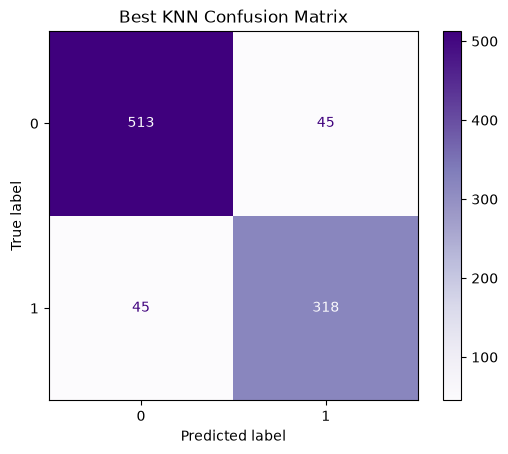

In [52]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    cmap="Purples"
)

plt.title("Best KNN Confusion Matrix")

plt.show()

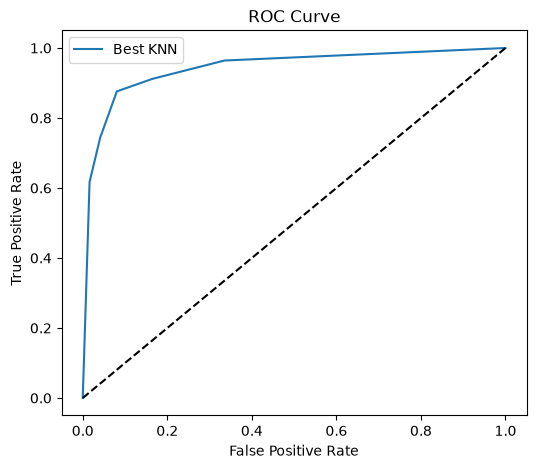

In [53]:
fpr,tpr,_=roc_curve(y_test,best_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label="Best KNN")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

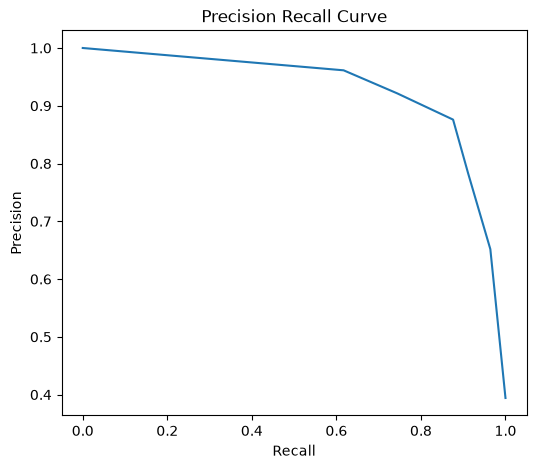

In [54]:
precision,recall,_=precision_recall_curve(
    y_test,
    best_prob
)

plt.figure(figsize=(6,5))

plt.plot(recall,precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [57]:
#comparions among the naive bayes

nb_table = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],

    "Gaussian":[
        gnb_accuracy,
        gnb_precision,
        gnb_recall,
        gnb_f1,
        gnb_auc
    ],

    "Multinomial":[
        mnb_accuracy,
        mnb_precision,
        mnb_recall,
        mnb_f1,
        mnb_auc
    ],

    "Bernoulli":[
        bnb_accuracy,
        bnb_precision,
        bnb_recall,
        bnb_f1,
        bnb_auc
    ]

})

nb_table


,Metric,Gaussian,Multinomial,Bernoulli
0,Accuracy,0.832790,0.893594,0.634093
1,Precision,0.714579,0.943144,0.964286
2,Recall,0.958678,0.776860,0.074380
3,F1,0.818824,0.851964,0.138107
4,ROC-AUC,0.922917,0.962454,0.587503


In [58]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'algorithm': ['auto', 'kd_tree', 'ball_tree']
}

grid_knn = KNeighborsClassifier()

start = time.time()

grid = GridSearchCV(
    estimator=grid_knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

grid_time = time.time() - start

print("Best Parameters")
print(grid.best_params_)

print("\nBest Accuracy")
print(grid.best_score_)

Best Parameters
{'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}

Best Accuracy
0.9179347826086957


In [59]:
grid_table = pd.DataFrame({

    "Parameter":[
        "Best k",
        "Metric",
        "Weights",
        "Algorithm",
        "CV Accuracy",
        "Execution Time"
    ],

    "GridSearchCV":[
        grid.best_params_['n_neighbors'],
        grid.best_params_['metric'],
        grid.best_params_['weights'],
        grid.best_params_['algorithm'],
        grid.best_score_,
        grid_time
    ]

})

grid_table

,Parameter,GridSearchCV
0,Best k,7
1,Metric,manhattan
2,Weights,distance
3,Algorithm,auto
4,CV Accuracy,0.917935
5,Execution Time,4.826735


In [60]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_neighbors': range(1,20),
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan'],
    'algorithm':['auto','kd_tree','ball_tree']
}

random_knn = KNeighborsClassifier()

start = time.time()

random = RandomizedSearchCV(
    estimator=random_knn,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random.fit(X_train,y_train)

random_time = time.time()-start

print(random.best_params_)
print(random.best_score_)

{'weights': 'distance', 'n_neighbors': 12, 'metric': 'manhattan', 'algorithm': 'kd_tree'}
0.9184782608695652


In [61]:
comparison = pd.DataFrame({

    "Parameter":[
        "Best k",
        "Metric",
        "Weights",
        "Algorithm",
        "CV Accuracy",
        "Execution Time"
    ],

    "GridSearchCV":[
        grid.best_params_['n_neighbors'],
        grid.best_params_['metric'],
        grid.best_params_['weights'],
        grid.best_params_['algorithm'],
        grid.best_score_,
        grid_time
    ],

    "RandomizedSearchCV":[
        random.best_params_['n_neighbors'],
        random.best_params_['metric'],
        random.best_params_['weights'],
        random.best_params_['algorithm'],
        random.best_score_,
        random_time
    ]

})

comparison

,Parameter,GridSearchCV,RandomizedSearchCV
0,Best k,7,12
1,Metric,manhattan,manhattan
2,Weights,distance,distance
3,Algorithm,auto,kd_tree
4,CV Accuracy,0.917935,0.918478
5,Execution Time,4.826735,0.816837


In [62]:
kd = KNeighborsClassifier(
    n_neighbors=best_k,
    algorithm='kd_tree'
)

start=time.time()
kd.fit(X_train,y_train)
kd_train=time.time()-start

start=time.time()
kd_pred=kd.predict(X_test)
kd_pred_time=time.time()-start

kd_acc=accuracy_score(y_test,kd_pred)

In [63]:
ball = KNeighborsClassifier(
    n_neighbors=best_k,
    algorithm='ball_tree'
)

start=time.time()
ball.fit(X_train,y_train)
ball_train=time.time()-start

start=time.time()
ball_pred=ball.predict(X_test)
ball_pred_time=time.time()-start

ball_acc=accuracy_score(y_test,ball_pred)

In [64]:
tree_table = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Training Time",
        "Prediction Time"
    ],

    "KDTree":[
        kd_acc,
        kd_train,
        kd_pred_time
    ],

    "BallTree":[
        ball_acc,
        ball_train,
        ball_pred_time
    ]

})

tree_table

,Metric,KDTree,BallTree
0,Accuracy,0.902280,0.902280
1,Training Time,0.018479,0.012917
2,Prediction Time,0.078620,0.073076


In [65]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

gnb_cv = cross_val_score(
    GaussianNB(),
    X_scaled,
    y,
    cv=cv,
    scoring='accuracy'
)

In [66]:
knn_cv = cross_val_score(
    best_knn,
    X_scaled,
    y,
    cv=cv,
    scoring='accuracy'
)

In [68]:
cv_table = pd.DataFrame({

    "Fold":[1,2,3,4,5,"Average"],

    "Naive Bayes":list(gnb_cv)+[gnb_cv.mean()],

    "Best KNN":list(knn_cv)+[knn_cv.mean()]

})

cv_table

,Fold,Naive Bayes,Best KNN
0,1,0.820847,0.896851
1,2,0.808696,0.894565
2,3,0.801087,0.901087
3,4,0.821739,0.905435
4,5,0.825000,0.895652
5,Average,0.815474,0.898718


In [69]:
time_table = pd.DataFrame({

    "Algorithm":[
        "Gaussian NB",
        "Multinomial NB",
        "Bernoulli NB",
        "Best KNN"
    ],

    "Training(s)":[
        gnb_train_time,
        mnb_train_time,
        bnb_train_time,
        best_knn_train_time
    ],

    "Prediction(s)":[
        gnb_pred_time,
        mnb_pred_time,
        bnb_pred_time,
        best_knn_pred_time
    ]

})

time_table

,Algorithm,Training(s),Prediction(s)
0,Gaussian NB,0.003612,0.001165
1,Multinomial NB,0.004425,0.001073
2,Bernoulli NB,0.006874,0.002449
3,Best KNN,0.001924,0.006040


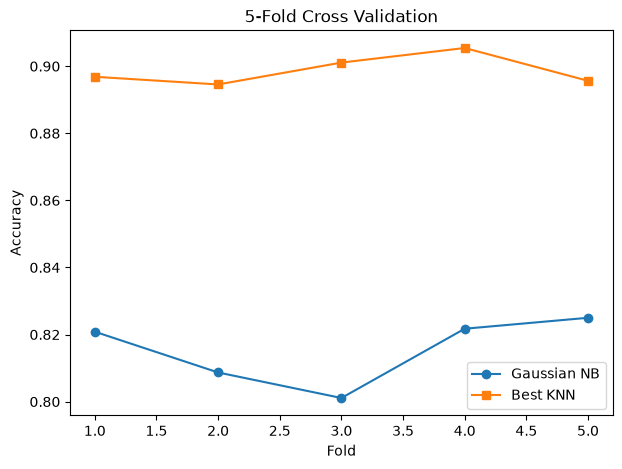

In [70]:
plt.figure(figsize=(7,5))

plt.plot(range(1,6),gnb_cv,marker='o',label='Gaussian NB')
plt.plot(range(1,6),knn_cv,marker='s',label='Best KNN')

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation")

plt.legend()

plt.show()

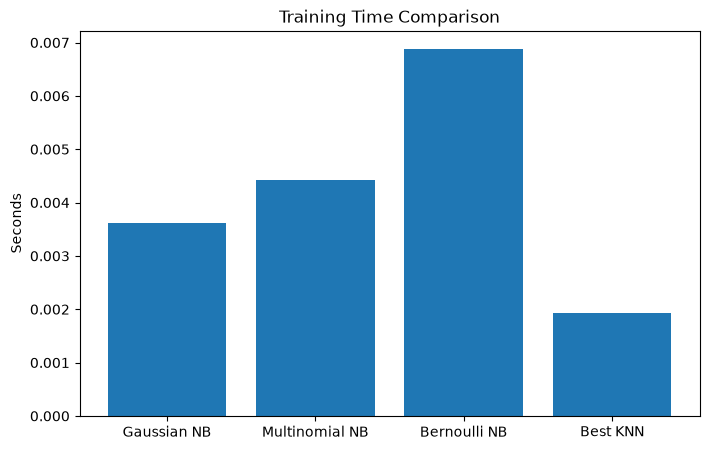

In [71]:
plt.figure(figsize=(8,5))

plt.bar(
    time_table["Algorithm"],
    time_table["Training(s)"]
)

plt.title("Training Time Comparison")
plt.ylabel("Seconds")

plt.show()

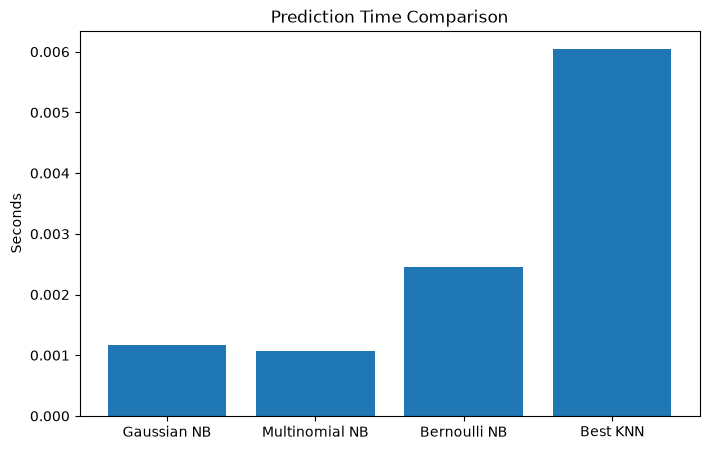

In [72]:
plt.figure(figsize=(8,5))

plt.bar(
    time_table["Algorithm"],
    time_table["Prediction(s)"]
)

plt.title("Prediction Time Comparison")
plt.ylabel("Seconds")

plt.show()

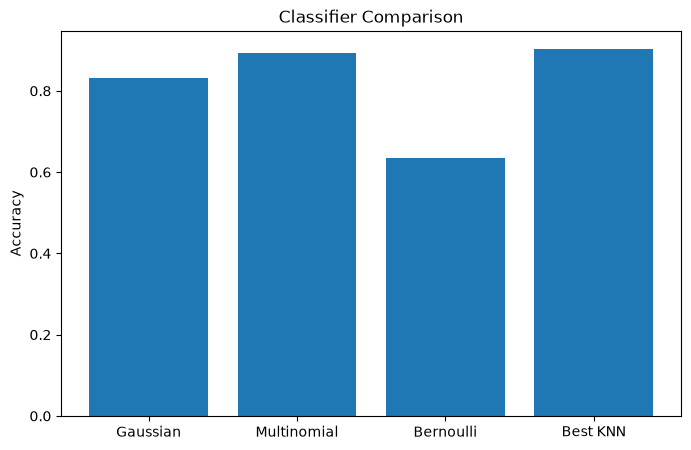

In [73]:
classifier_names = [
    "Gaussian",
    "Multinomial",
    "Bernoulli",
    "Best KNN"
]

classifier_accuracy = [
    gnb_accuracy,
    mnb_accuracy,
    bnb_accuracy,
    best_accuracy
]

plt.figure(figsize=(8,5))

plt.bar(
    classifier_names,
    classifier_accuracy
)

plt.ylabel("Accuracy")
plt.title("Classifier Comparison")

plt.show()

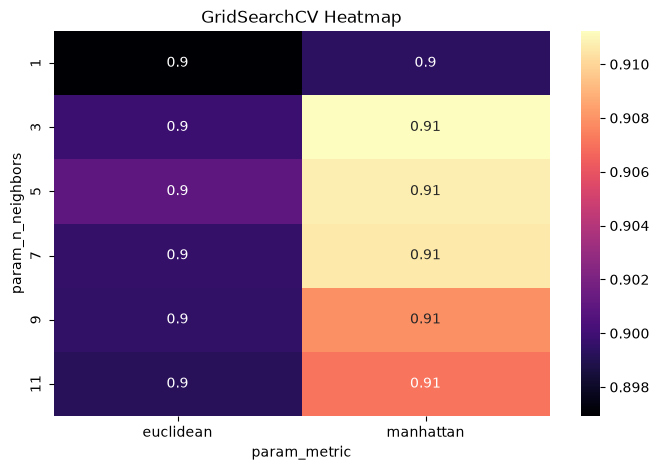

In [76]:
grid_results = pd.DataFrame(grid.cv_results_)

pivot = grid_results.pivot_table(
    values='mean_test_score',
    index='param_n_neighbors',
    columns='param_metric'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap='magma'
)

plt.title("GridSearchCV Heatmap")

plt.show()

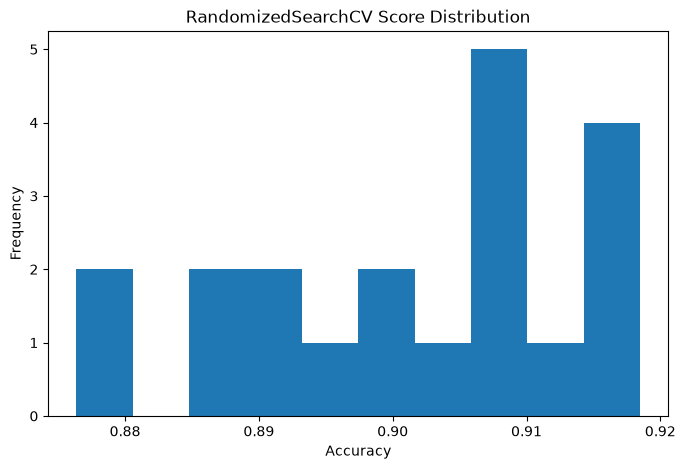

In [75]:
plt.figure(figsize=(8,5))

plt.hist(
    random.cv_results_['mean_test_score'],
    bins=10
)

plt.title("RandomizedSearchCV Score Distribution")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")

plt.show()